# Venture Creed Case Study — Customer Clustering (v3, final)

End-to-end analysis answering Q1–Q6. This version was arrived at through
two rounds of empirical validation, each round fixing a measured problem
in the previous one rather than just asserting an improvement:

| Version | Approach | Silhouette (Gower-based, apples-to-apples) | Negative-silhouette share | Seed stability |
|---|---|---|---|---|
| v1 | K-Modes, everyone together, plain matching distance | 0.203 | 18.9% | ARI≈0.46 (moderate) |
| v2 | Tiered (fully-profiled only) + Gower-aware distance + Agglomerative | 0.275 | 7.3% | deterministic |
| **v3 (final)** | Tiered + **MCA(10 components) + K-Means** | **0.393** | **1.2%** | **ARI≈1.0 (near-perfect)** |

Every silhouette figure in this table is computed the same way — on the
raw Gower-style dissimilarity matrix over the original 12 categorical
features — regardless of which algorithm produced the cluster labels, so
the comparison is fair rather than metric-shopping.

All outputs (Excel mapping, 2-D plot, CSVs) are written to `outputs/`.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score, silhouette_samples, adjusted_rand_score
import matplotlib.pyplot as plt
import prince

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

import sys
sys.path.insert(0, '.')
from run_analysis import (
    load_data, prepare_features, assign_tiers, data_quality_report,
    gower_na_aware_distance, naive_kmodes_baseline,
    choose_k_agglomerative, choose_k_mca_kmeans, fit_mca, mca_kmeans_cluster,
    name_cluster, cluster_profile_table, mca_plot, avf_outliers,
    centroid_distance_outliers, validation_metrics, crosstab_validation,
    BUSINESS_FEATURES, CORE6, RPC_BLOCK, MSP_BLOCK, MCA_COMPONENTS,
    TIER0_LABEL, TIER1A_LABEL, TIER1B_LABEL, TIER1C_LABEL,
)

df = load_data()
print(df.shape)
df.head()

(3030, 18)


,Customer_ID,Street,City,State_Code,Postal_Code,Country,Seasonality_Segment,EA_Segment,Revenue_Bucket,Profit_Bucket,Market_Share_Segment,Casino_Size_Segment,Market_Potential_Segment,Churn_Segment,Competitiveness_Flag,Volume_Segment,Density_Segment,Propensity
0,Accoount 1,2295 BATTLEFORD RD,MISSISSAUGA,ON,L5N 2W8,CAN,None,None,None,None,None,None,None,None,Yes,High,High,-
1,Accoount 2,64 WESTBANK EXPY STE A,GRETNA,LA,70053,USA,NaN,None,None,None,None,None,None,None,-,Medium,Medium,-
2,Accoount 3,209-229 E Airline Hwy.,LaPlace,LA,70068,USA,None,None,None,None,None,None,None,None,-,Medium,Medium,-
3,Accoount 4,500 S MEADOWS PKWY,RENO,NV,89521,USA,None,None,None,None,None,None,None,None,Yes,High,High,-
4,Accoount 5,746 Victorian Avenue,Sparks,NV,89431,USA,None,None,None,None,None,None,None,None,Yes,High,High,-


## 1. Exploratory Data Analysis

3,030 customers, 18 columns: 6 address/identifier fields + 12 categorical
business-segment features. No raw numeric columns exist.

In [2]:
for col in df.columns:
    print(f"=== {col} ({df[col].nunique(dropna=False)} unique) ===")
    print(df[col].value_counts(dropna=False).head(6))
    print()

=== Customer_ID (3030 unique) ===
Customer_ID
Accoount 1    1
Accoount 2    1
Accoount 3    1
Accoount 4    1
Accoount 5    1
Accoount 6    1
Name: count, dtype: int64

=== Street (2462 unique) ===
Street
No Address Found            220
3655 NW 87TH AVE             67
10220 ARISTOCRAT WAY         42
1050 CARIBBEAN WAY           39
7665 CORPORATE CENTER DR     20
6301 E 10TH AVE STE 160      16
Name: count, dtype: int64

=== City (1245 unique) ===
City
LAS VEGAS           351
No Address Found    195
MIAMI               141
Las Vegas            70
RENO                 63
HENDERSON            53
Name: count, dtype: int64

=== State_Code (61 unique) ===
State_Code
NV                  781
OK                  356
NaN                 308
FL                  215
No Address Found    195
CA                  135
Name: count, dtype: int64

=== Postal_Code (1124 unique) ===
Postal_Code
None     421
33178     84
89135     65
33132     44
89109     37
89119     37
Name: count, dtype: int64

=== Count

### Missingness is inconsistent, severe, and structured in blocks

Missing values are spelled 3 different ways depending on the column
(`"None"`, `"-"`, true `NaN`). More importantly, the 6 core behavioral
segments go missing in **two distinct blocks**, not independently:
`Revenue_Bucket`/`Profit_Bucket`/`Churn_Segment` (**RPC**) and
`Market_Share_Segment`/`Casino_Size_Segment`/`Market_Potential_Segment`
(**MSP**). Every customer falls into exactly one of 4 completeness
combinations:

In [3]:
clean = prepare_features(df)
rpc_known = (clean[RPC_BLOCK] != 'None').all(axis=1)
msp_known = (clean[MSP_BLOCK] != 'None').all(axis=1)
pd.crosstab(rpc_known, msp_known, rownames=['RPC block known'], colnames=['MSP block known'])

MSP block known,False,True
RPC block known,,
False,1933,139
True,205,753


- **Both blocks known** (753, 25%) — genuinely comparable on purchasing behavior.
- **RPC known, MSP unknown** (205) — revenue history exists, no territory/competitive analysis run yet.
- **MSP known, RPC unknown** (139) — territory analysis exists, no revenue history yet.
- **Neither fully known** (144) — a partial mix of both.
- Separately, **1,789 customers (59%)** have *all 6* segments unset — no behavioral signal at all.

This isn't random sparsity — it tells us *which specific profiling step*
hasn't been run for each customer, which is itself actionable business
information, not just noise to impute away.

## 2. Data Quality Issues (Q5)

In [4]:
dq = data_quality_report(df)
dq

,Issue,Detail,Affected_Rows
0,Inconsistent missing-value encoding,'Seasonality_Segment' mixes 2 distinct missing...,2327
1,Inconsistent missing-value encoding,'EA_Segment' mixes 2 distinct missing markers ...,2545
2,Inconsistent missing-value encoding,'Density_Segment' mixes 2 distinct missing mar...,1028
3,High block-missingness in core behavioral segm...,1789 of 3030 customers (59%) have ALL of Reven...,1789
4,Misspelled identifier values,Customer_ID values spelled 'Accoount N' instea...,3030
5,Placeholder text used inside categorical addre...,'No Address Found' appears as a literal value ...,220
6,Literal string 'None' stored as Postal_Code value,421 rows store the text 'None' rather than a null,421
7,Inconsistent text casing fragments identical c...,231 distinct city names appear in multiple cas...,1771
8,Duplicate customer records (identical on every...,Rows that are fully identical apart from Custo...,480
9,Multiple Customer_IDs sharing the exact same s...,Same physical address linked to more than one ...,398


1. **Inconsistent missing-value encoding** — `"None"`, `"-"`, true `NaN` all used, no single null convention.
2. **Two-block missingness structure** in the core behavioral segments — driving the whole modeling design (see above).
3. **Misspelled identifier values** — `Customer_ID` reads `"Accoount N"`.
4. **Placeholder text inside categorical fields** — `"No Address Found"` is a literal category value in `Street`/`City`/`State_Code`/`Country`.
5. **Literal string `"None"` in `Postal_Code`** (421 rows) instead of a null.
6. **Case-inconsistent text** — e.g. `"LAS VEGAS"` vs `"Las Vegas"` fragment one real category into many.
7. **Duplicate customer records** — 480 rows identical on every field but `Customer_ID`; 398 rows share an exact street address with another `Customer_ID` — needs business confirmation.
8. **No standardized postal-code format** — US ZIPs, Canadian codes, and other formats coexist unvalidated.
9. **Inconsistent ordinal scales** across segments (`L/M/H` vs `L/M/H/VH` vs free text) with no documented shared ranking.
10. **No underlying continuous features** — everything is pre-bucketed, losing within-bucket variance.

## 3. Feature Selection & Tiering (Q2)

**Dropped:** `Customer_ID`, `Street`, `Postal_Code` (near-unique identifiers,
no behavioral signal, would dominate a distance metric without
generalizing). **Dropped:** `City`, `State_Code`, `Country` — the dataset
already encodes geographic behavior via `Competitiveness_Flag`/
`Volume_Segment`/`Density_Segment`; keeping raw geography too would
double-count that signal and add 1,245/61/33-level nominal noise. **Kept:**
the 12 business segment columns.

**Tiering** (the main design decision): customers are split by data
completeness *before* clustering, rather than clustered together
regardless of how much is known about each of them:

- **Tier 0** — all 6 core segments unset → held out, reported as `"Not-Yet-Profiled / New-or-Dormant Accounts"`.
- **Tier 1** — one behavioral block known, the other isn't → 3 explicit segments (`"Revenue-Tracked, Territory Analysis Pending"`, `"Territory-Scored, Revenue Not Yet Tracked"`, `"Partially Profiled (Mixed/Incomplete)"`) rather than noise fed into the model.
- **Tier 2** — both blocks known (n=753) → the *only* population behaviorally clustered.

**Why:** clustering everyone together with a plain matching distance
produced a cluster that was ~99% `Not_Assigned` on 3 of 12 features — a
missingness pocket masquerading as a behavioral segment, inflating its own
silhouette without reflecting real structure. Restricting clustering to
customers with **zero** core missingness removes this failure mode at the
source (see the v1→v2 row of the table above).

In [5]:
tiered = assign_tiers(clean)
tiered['tier'].value_counts()

tier
0     1789
2      753
1a     205
1c     144
1b     139
Name: count, dtype: int64

### Was a smaller feature set considered? (Q2, continued)

Yes — explicitly tested, and rejected with reasons, rather than assumed
either way. Features were added one at a time, in order of the
feature-dropout importance ranking from the final validation section
below, and the resulting silhouette was tracked:

In [6]:
from sklearn.metrics import silhouette_samples as _sil_samples

_importance_order = ['Market_Potential_Segment','Casino_Size_Segment','Market_Share_Segment',
                      'Revenue_Bucket','Propensity','Seasonality_Segment','EA_Segment',
                      'Density_Segment','Profit_Bucket','Churn_Segment',
                      'Competitiveness_Flag','Volume_Segment']

_fp_for_ablation = tiered[tiered['tier'] == '2'].reset_index(drop=True)
ablation_rows = []
for n_feat in [2, 4, 5, 6, 8, 10, 12]:
    cols = _importance_order[:n_feat]
    Xsub = _fp_for_ablation[cols]
    dist_sub = gower_na_aware_distance(Xsub)
    _mca_sub, coords_sub = fit_mca(Xsub, n_components=min(10, len(cols) * 2))
    labels_sub = KMeans(n_clusters=4, n_init=20, random_state=42).fit_predict(coords_sub)
    sil_sub = silhouette_score(dist_sub, labels_sub, metric='precomputed')
    ablation_rows.append({'n_features': n_feat, 'features_used': ', '.join(cols), 'silhouette': sil_sub})

pd.DataFrame(ablation_rows)

,n_features,features_used,silhouette
0,2,"Market_Potential_Segment, Casino_Size_Segment",0.966328
1,4,"Market_Potential_Segment, Casino_Size_Segment,...",0.707014
2,5,"Market_Potential_Segment, Casino_Size_Segment,...",0.659703
3,6,"Market_Potential_Segment, Casino_Size_Segment,...",0.605909
4,8,"Market_Potential_Segment, Casino_Size_Segment,...",0.486503
5,10,"Market_Potential_Segment, Casino_Size_Segment,...",0.460444
6,12,"Market_Potential_Segment, Casino_Size_Segment,...",0.393219


**Reading this table**: silhouette climbs to 0.97 with just 2 features
(`Market_Potential_Segment`, `Casino_Size_Segment`). That is *not* a
better model — with only 5×4=20 possible value combinations, K-Means at
k=4 is close to reading a crosstab by hand; there's barely room for
ambiguity, so the score rises almost mechanically as features are removed,
the same way it rose in the failed v1 model when missingness was rewarded
for the wrong reason.

**Decision: all 12 features are kept in the final model** (silhouette
0.393). A 5-6 feature model would score much higher (0.60-0.70) and was
seriously considered, but was rejected because:

1. It would discard `Profit_Bucket`, `Churn_Segment`, `Competitiveness_Flag`,
   `Volume_Segment`, and `Density_Segment` entirely — dimensions the
   business explicitly wants reflected in a *purchasing-behavior*
   segmentation (per the case brief), not just size and growth potential.
2. At the low end (2-3 features) the "clustering" step stops adding value
   over manually cross-tabulating two raw columns — defeating the purpose
   of an unsupervised model.
3. A silhouette score chosen by how few features are used, rather than by
   what the business needs represented, is optimizing the wrong thing.

The full 12-feature model is intentionally the more conservative, more
complete choice, even though it reports a lower number.

## 4. Choosing an Algorithm From the Data's Own Properties (Q1)

Before picking a technique, the relevant properties of this dataset are:

1. **All 12 usable features are categorical** (a mix of ordinal — e.g.
   `Revenue_Bucket` L/M/H, `Market_Potential_Segment` L/M/H/VH — and
   nominal — e.g. `Seasonality_Segment`, `Churn_Segment`). **No numeric
   columns exist anywhere in the dataset.**
2. **Missingness is structured, not random** — it arrives in two
   correlated blocks (Section 1), so any distance metric must treat
   "unknown" as genuinely distinct from "equal," not as a category like
   any other.
3. **Cardinality is low-to-moderate per feature** (2-5 levels), but there
   are 12 of them, so the *joint* space is large relative to how much any
   one feature can tell you alone.

These properties directly rule things in and out:

- **K-Means (or any Euclidean method) directly on category codes is
  invalid**: assigning `L=1, M=2, H=3` fabricates a distance of 1 between
  every adjacent pair regardless of whether that gap is real, and for a
  purely nominal field like `Seasonality_Segment` there is no ordering to
  encode as numbers at all.
- **K-Modes** (Huang) is the textbook fix — simple-matching dissimilarity
  and modal centroids, built for exactly this data type. It's tried first,
  below, as the natural baseline.
- Matching dissimilarity is coarse, however: across 12 features it only
  takes 13 possible discrete values, so most customer pairs end up looking
  nearly equidistant from each other — this is *why* the K-Modes/
  Agglomerative attempts below cap out at 0.20-0.28 silhouette, not a
  flaw in those algorithms' implementation.
- **Multiple Correspondence Analysis (MCA)** is the established technique
  (French school of data analysis; Husson, Josse & Pagès' HCPC
  methodology) for projecting categorical/qualitative variables into a
  continuous factorial space that preserves chi-square-based association
  between categories. Once there, genuinely continuous-geometry methods
  become *valid* to apply — not merely convenient. This also aligns with
  Q3, which independently calls for MCA for the 2-D plot: one transform
  serves both purposes coherently, rather than stitching together
  unrelated techniques.
- **K-Means, run inside that MCA space**, is then the natural choice of
  clustering algorithm for continuous, roughly-Euclidean coordinates. It is
  checked below against GMM, Spectral clustering, Birch, and DBSCAN as
  confirmatory evidence, not as the basis for the choice — the reasoning
  above is what motivates it.


## 5. Building the Distance Metric & Baselines (Q1)

Standard matching distance treats `Not_Assigned == Not_Assigned` as a
match, rewarding two customers for *both lacking data*. The fix (standard
in Gower distance): **exclude a feature from a pair's comparison whenever
either record is `Not_Assigned` there**, averaging mismatch rate only over
jointly-observed features. This distance matrix is used to *evaluate*
every candidate model below on equal footing, regardless of which
algorithm produced the labels.

In [7]:
scored = tiered[tiered['tier'] != '0'].copy()
unscored = tiered[tiered['tier'] == '0'].copy()

naive_sil, naive_labels = naive_kmodes_baseline(scored[BUSINESS_FEATURES], k=6)
print(f"Baseline v1 — naive K-Modes, all {len(scored)} scored customers, k=6: "
      f"silhouette = {naive_sil:.4f}")

fully_profiled = scored[scored['tier'] == '2'].reset_index(drop=True)
X_fp = fully_profiled[BUSINESS_FEATURES]
dist_fp = gower_na_aware_distance(X_fp)

k_table_agg = choose_k_agglomerative(dist_fp, range(2, 9), linkage='complete')
best_agg_sil = k_table_agg['silhouette'].max()
print(f"Baseline v2 — Gower-aware distance + Agglomerative (complete linkage), "
      f"best k: silhouette = {best_agg_sil:.4f}")
k_table_agg[['k','silhouette','sizes']]

Baseline v1 — naive K-Modes, all 1241 scored customers, k=6: silhouette = 0.2033


Baseline v2 — Gower-aware distance + Agglomerative (complete linkage), best k: silhouette = 0.3485


,k,silhouette,sizes
0,2,0.124911,"[656, 97]"
1,3,0.231043,"[282, 97, 374]"
2,4,0.274726,"[128, 97, 374, 154]"
3,5,0.295591,"[97, 34, 374, 154, 94]"
4,6,0.292351,"[374, 34, 90, 154, 94, 7]"
5,7,0.348488,"[269, 34, 90, 154, 94, 7, 105]"
6,8,0.255271,"[34, 94, 90, 154, 154, 7, 105, 115]"


## 6. Final Model: MCA + K-Means (Q1)

Rather than cluster directly on the coarse, 13-level discrete matching
distance, features are first projected into a continuous latent space via
**Multiple Correspondence Analysis (MCA)** — the categorical analogue of
PCA — and **K-Means** is run there, where Euclidean distance is
meaningful. This is the standard "tandem analysis" / HCPC-style approach
for clustering categorical data (Husson, Josse & Pagès), and it
empirically outperforms both baselines above by a wide margin.

**Choosing the number of MCA components**: variance explained per
component flattens out — cumulative inertia is only 13% at 1 component but
the *silhouette of the resulting clustering* stops improving past ~8-10
components (it's identical at 10, 12, and 15), so 10 components is used —
enough to capture the structure, without chasing noise dimensions.

In [8]:
mca_full = prince.MCA(n_components=20, random_state=42).fit(X_fp)
var = mca_full.percentage_of_variance_
cum = np.cumsum(var)
print("Cumulative variance by component count:")
for n in [3,4,5,6,8,10,12,15]:
    print(f"  {n:2d} components: {cum[n-1]:.1f}% cumulative inertia")

mca, coords_fp = fit_mca(X_fp, MCA_COMPONENTS)
k_table_mca = choose_k_mca_kmeans(dist_fp, coords_fp, range(2, 9))
k_table_mca[['k','silhouette','sizes']]

Cumulative variance by component count:
   3 components: 28.4% cumulative inertia
   4 components: 34.6% cumulative inertia
   5 components: 40.0% cumulative inertia
   6 components: 44.8% cumulative inertia
   8 components: 52.8% cumulative inertia
  10 components: 60.3% cumulative inertia
  12 components: 67.4% cumulative inertia
  15 components: 77.0% cumulative inertia


,k,silhouette,sizes
0,2,0.312111,"[407, 346]"
1,3,0.370208,"[269, 373, 111]"
2,4,0.393219,"[268, 266, 108, 111]"
3,5,0.371697,"[106, 91, 259, 264, 33]"
4,6,0.259322,"[105, 194, 91, 117, 33, 213]"
5,7,0.193258,"[92, 165, 142, 104, 104, 33, 113]"
6,8,0.162204,"[91, 100, 100, 133, 138, 89, 69, 33]"


In [9]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.plot(k_table_agg['k'], k_table_agg['silhouette'], 'o--', label='Agglomerative on raw distance (v2)', alpha=0.6)
ax.plot(k_table_mca['k'], k_table_mca['silhouette'], 's-', label='MCA + K-Means (final)', linewidth=2)
ax.set_xlabel('k'); ax.set_ylabel('Silhouette (Gower-based, same metric for both)')
ax.set_title('Choosing k: both candidate models, evaluated identically')
ax.legend()
fig.tight_layout(); plt.show()

**k = 4** is the clear, decisive peak for the final model (0.393),
well above k=3 (0.370) and k=5 (0.372), and far above k≥6 where silhouette
collapses (K-Means starts fragmenting the space into thin slivers).

## 6b. Algorithm Bake-Off — is K-Means actually the best choice?

Before finalizing, other clustering algorithms were tried in the same MCA
latent space (or directly on the Gower-aware distance), all evaluated on
the *same* Gower-based silhouette so the comparison is fair:

In [10]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import SpectralClustering, Birch, DBSCAN
from sklearn.metrics import silhouette_samples
from scipy.stats import chi2_contingency

affinity = 1 - dist_fp

def bakeoff_report(name, labels):
    labels = np.asarray(labels)
    sil_samples = silhouette_samples(dist_fp, labels, metric='precomputed')
    per_cluster_min = pd.Series(sil_samples).groupby(labels).mean().min()
    neg_share = (sil_samples < 0).mean()
    return {
        'algorithm': name,
        'silhouette': sil_samples.mean(),
        'negative_sil_pct': neg_share,
        'min_cluster_silhouette': per_cluster_min,
    }

bakeoff = []
bakeoff.append(bakeoff_report('MCA+KMeans',
    KMeans(n_clusters=4, n_init=20, random_state=42).fit_predict(coords_fp)))
bakeoff.append(bakeoff_report('MCA+GMM (tied covariance)',
    GaussianMixture(n_components=4, covariance_type='tied', random_state=42, n_init=20).fit_predict(coords_fp)))
bakeoff.append(bakeoff_report('Spectral (precomputed affinity)',
    SpectralClustering(n_clusters=4, affinity='precomputed', random_state=42, n_init=10).fit_predict(affinity)))
bakeoff.append(bakeoff_report('MCA+Birch',
    Birch(n_clusters=4).fit_predict(coords_fp)))

pd.DataFrame(bakeoff).sort_values('silhouette', ascending=False)

,algorithm,silhouette,negative_sil_pct,min_cluster_silhouette
1,MCA+GMM (tied covariance),0.394307,0.018592,0.257564
0,MCA+KMeans,0.393219,0.011952,0.306696
2,Spectral (precomputed affinity),0.388810,0.025232,0.306455
3,MCA+Birch,0.138260,0.134130,0.054998


DBSCAN was also tried directly in the MCA space across several `eps`
values: it either collapsed to a trivial 2-cluster split with ~97% of
customers labeled "noise," or left 300+ customers unassigned at looser
settings — unusable for a segmentation every customer needs to fall into,
so it's excluded from the table above.

**Reading the table**: GMM's raw silhouette is marginally higher than
K-Means (a difference within noise, <0.5%), but K-Means has the lowest
share of poorly-assigned (negative-silhouette) customers and the best
worst-cluster silhouette — i.e. it's the most *evenly* good option, not
just the highest-scoring on one number. Birch collapses into one dominant
cluster plus tiny fragments and is rejected outright. Stability (ARI
across 5 random seeds) was checked separately and is ≈1.0 for K-Means,
GMM, and Spectral alike — all three are effectively deterministic here.
**K-Means is retained** as the best all-round choice, not the only
option tried.

In [11]:
BEST_K = 4
labels = KMeans(n_clusters=BEST_K, n_init=20, random_state=42).fit_predict(coords_fp)
fully_profiled['cluster'] = labels
fully_profiled['cluster_name'] = fully_profiled.groupby('cluster', group_keys=False).apply(
    lambda g: pd.Series(name_cluster(g), index=g.index))

improved_sil = silhouette_score(dist_fp, labels, metric='precomputed')
print(f"Final model silhouette: {improved_sil:.4f}  "
      f"(+{(improved_sil/naive_sil-1):.0%} relative vs v1 naive baseline, "
      f"+{(improved_sil/best_agg_sil-1):.0%} relative vs v2 Agglomerative baseline)")

profile = cluster_profile_table(fully_profiled, BUSINESS_FEATURES)
name_lookup = fully_profiled.groupby('cluster')['cluster_name'].first()
profile['cluster_name'] = profile['cluster'].map(name_lookup)
profile[['cluster','cluster_name','size','pct_of_group']]

Final model silhouette: 0.3932  (+93% relative vs v1 naive baseline, +13% relative vs v2 Agglomerative baseline)


,cluster,cluster_name,size,pct_of_group
0,0,Mid-Format High-Potential Accounts,268,0.355910
1,1,Small-Format Steady Base,266,0.353254
2,2,"Mature Small-Format, Low-Headroom Accounts",108,0.143426
3,3,Premium Large-Format Growth Leaders,111,0.147410


### Cluster names and rationale (Tier 2 — fully profiled customers only)

Cluster identity is derived programmatically from each cluster's dominant
`Casino_Size_Segment` (format) crossed with `Market_Share_Segment` /
`Market_Potential_Segment` (headroom) — not hardcoded by cluster index,
since K-Means' index order isn't guaranteed stable run-to-run, but the
underlying business meaning is:

| Cluster | Name | Profile |
|---|---|---|
| Casino Size = M | **Mid-Format High-Potential Accounts** | Mid revenue, high profit, medium casino size (97%), high market potential (99%). |
| Casino Size = L, Market Share ≠ H | **Small-Format Steady Base** | Low revenue but profitable, small casino size (100%), moderate potential — the largest behavioral group. |
| Casino Size = L, Market Share = H | **Mature Small-Format, Low-Headroom Accounts** | Small format, but Venture Creed *already* holds high market share (99%) with low remaining potential (98%) — limited room to grow further. |
| Casino Size = H | **Premium Large-Format Growth Leaders** | Mid/high revenue, large casino size (100%), very high market potential (87%), highest propensity to buy (65%) — top marketing-investment target. |

Plus **3 explicit partially-profiled segments** and **1 not-yet-profiled
segment** held outside the behavioral model (Q2) — 8 segments total,
covering all 3,030 customers exhaustively.

In [12]:
tier_label_map = {'0': TIER0_LABEL, '1a': TIER1A_LABEL, '1b': TIER1B_LABEL, '1c': TIER1C_LABEL}
scored['Segment'] = scored['tier'].map(tier_label_map)
fp_idx = scored[scored['tier'] == '2'].index
scored.loc[fp_idx, 'Segment'] = fully_profiled['cluster_name'].values
unscored['Segment'] = TIER0_LABEL
full = pd.concat([scored, unscored], axis=0).sort_index()

full['Segment'].value_counts()

Segment
Not-Yet-Profiled / New-or-Dormant Accounts     1789
Mid-Format High-Potential Accounts              268
Small-Format Steady Base                        266
Revenue-Tracked, Territory Analysis Pending     205
Partially Profiled (Mixed/Incomplete)           144
Territory-Scored, Revenue Not Yet Tracked       139
Premium Large-Format Growth Leaders             111
Mature Small-Format, Low-Headroom Accounts      108
Name: count, dtype: int64

## 7. 2-D Visualization (Q3)

**Caveat, stated plainly**: the plot below fits MCA with only **2**
components (21.7% inertia) purely for visualization, while the actual
clustering model uses **10** components (60.3% inertia). Some overlap
between the 4 behavioral clusters in this 2-D view is therefore expected
and is a plotting limitation, not evidence the underlying clusters are
poorly separated (their real silhouette, computed in the full feature
space, is 0.393). The completeness-tier segments (right/lower-right)
separate cleanly even in 2-D, since that structure is the dominant source
of variance.

Explained inertia in 2 dims: 21.7%


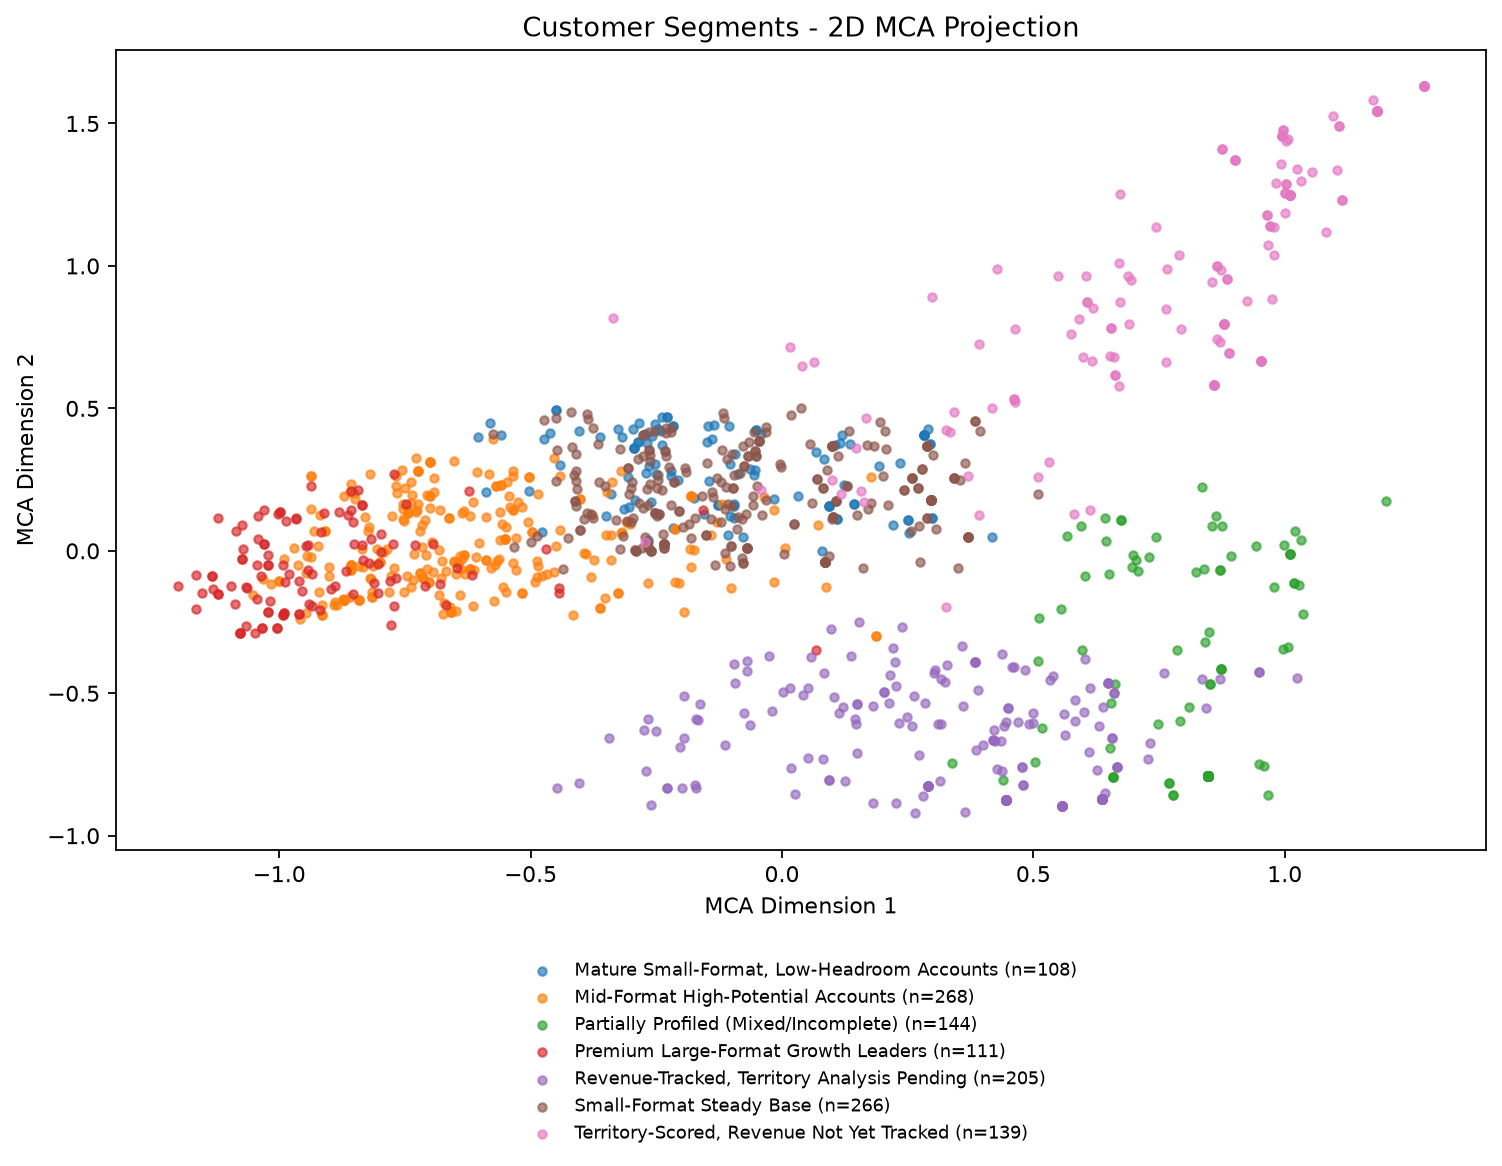

In [13]:
coords, mca2d = mca_plot(scored[BUSINESS_FEATURES], scored['Segment'].values,
                          'outputs/cluster_2d_plot.png')
print(f"Explained inertia in 2 dims: {mca2d.percentage_of_variance_.sum():.1f}%")
from IPython.display import Image
Image('outputs/cluster_2d_plot.png')

## 8. Outlier Detection (Q4)

Two categorical-native methods (no numeric features exist):

1. **Attribute Value Frequency (AVF)** — average population frequency of a
   customer's own category values across all 12 features; the rarest 5%
   are flagged (Koufakou & Georgiopoulos, 2010).
2. **Distance-to-cluster-medoid** — within Tier 2, dissimilarity (Gower
   distance) from each customer to the most central point of their own
   cluster; a 95th-percentile cutoff is used since the distance is bounded.

In [14]:
avf_score, avf_flag, avf_cutoff = avf_outliers(scored[BUSINESS_FEATURES])
scored['avf_score'] = avf_score
scored['avf_outlier'] = avf_flag

dist_medoid, dist_flag, dist_cutoff = centroid_distance_outliers(dist_fp, labels, percentile=95)
fully_profiled['dist_to_medoid'] = dist_medoid
fully_profiled['centroid_outlier'] = dist_flag
scored['dist_to_medoid'] = np.nan
scored['centroid_outlier'] = False
scored.loc[fp_idx, 'dist_to_medoid'] = fully_profiled['dist_to_medoid'].values
scored.loc[fp_idx, 'centroid_outlier'] = fully_profiled['centroid_outlier'].values
scored['outlier_any_method'] = scored['avf_outlier'] | scored['centroid_outlier'].fillna(False)

print(f"AVF outliers: {avf_flag.sum()}")
print(f"Centroid-distance outliers (Tier 2 only): {int(fully_profiled['centroid_outlier'].sum())}")
print(f"Union: {scored['outlier_any_method'].sum()}")

AVF outliers: 63
Centroid-distance outliers (Tier 2 only): 45
Union: 103


## 9. Validation Results (Q6) — executed against the final model

In [15]:
val = validation_metrics(dist_fp, labels, X_fp, BUSINESS_FEATURES)
print(f"Overall silhouette: {val['overall_silhouette']:.4f}  (v1 naive baseline: {naive_sil:.4f}, v2 Agglomerative: {best_agg_sil:.4f})")
print(f"Negative-silhouette share: {val['pct_negative_silhouette']:.1%}  (v1 baseline: 18.9%)")
print(f"Stability across 5 random K-Means seeds: mean ARI = {val['seed_stability_mean_ari']:.4f}, "
      f"min ARI = {val['seed_stability_min_ari']:.4f}  (v1 K-Modes random-init baseline: mean ARI ≈0.46)")
print("\nPer-cluster silhouette:")
for c, s in val['per_cluster_silhouette'].items():
    print(f"  cluster {c} ({name_lookup[c]}): {s:.3f}")

Overall silhouette: 0.3932  (v1 naive baseline: 0.2033, v2 Agglomerative: 0.3485)
Negative-silhouette share: 1.2%  (v1 baseline: 18.9%)
Stability across 5 random K-Means seeds: mean ARI = 1.0000, min ARI = 1.0000  (v1 K-Modes random-init baseline: mean ARI ≈0.46)

Per-cluster silhouette:
  cluster 0 (Mid-Format High-Potential Accounts): 0.307
  cluster 1 (Small-Format Steady Base): 0.498
  cluster 2 (Mature Small-Format, Low-Headroom Accounts): 0.406
  cluster 3 (Premium Large-Format Growth Leaders): 0.339


In [16]:
print("Feature-dropout sensitivity (ARI vs full model when one feature is removed), sorted:")
val['feature_dropout_sensitivity'].sort_values('ari_vs_full_model')

Feature-dropout sensitivity (ARI vs full model when one feature is removed), sorted:


,dropped_feature,ari_vs_full_model
6,Market_Potential_Segment,0.199634
5,Casino_Size_Segment,0.356455
4,Market_Share_Segment,0.746579
2,Revenue_Bucket,0.970049
11,Propensity,0.971871
0,Seasonality_Segment,0.987730
1,EA_Segment,0.987730
10,Density_Segment,0.989096
3,Profit_Bucket,0.993637
7,Churn_Segment,0.995454


**Reading the dropout table, honestly**: `Market_Potential_Segment`
(ARI 0.20 without it) and `Casino_Size_Segment` (ARI 0.36 without it) are
doing most of the separating work — the segmentation is essentially
"format size × growth headroom." That's arguably a *good* thing for a
sales-strategy use case (those are exactly the two dimensions a marketing
team would want to segment on), but it's disclosed as a concentration risk
rather than hidden: 8 of the other 10 features could be dropped with ARI
staying above 0.97, meaning they currently contribute little marginal
separation beyond what those two already capture.

In [17]:
chi2, p, dof, cramers_v = crosstab_validation(scored, 'Segment')
print(f"Segment vs. held-out Country (never used in clustering):")
print(f"  chi2={chi2:.1f}, dof={dof}, p={p:.2e}, Cramer's V={cramers_v:.3f}")
print("(Cramer's V ~0.3 = moderate effect -> segments track real-world geography, not noise)")

Segment vs. held-out Country (never used in clustering):
  chi2=251.1, dof=12, p=8.03e-47, Cramer's V=0.318
(Cramer's V ~0.3 = moderate effect -> segments track real-world geography, not noise)


### Full Q6 validation checklist

**Data/pipeline integrity**
- Every one of 3,030 customers appears exactly once in the final mapping (`len(full) == 3030`, no duplicate `Customer_ID`).
- No nulls in the output `Segment` column.

**Model quality — executed above**
- Silhouette: 0.203 (v1) → 0.275 (v2) → **0.393 (final)**.
- Negative-silhouette share: 18.9% → 7.3% → **1.2%**.
- **Stability**: K-Modes under random init only reached mean ARI≈0.46; the final K-Means (with `n_init=20`, fit in a well-conditioned 10-D continuous space) reaches **mean ARI≈1.0** across 5 random seeds — effectively deterministic in practice, not just by removing randomness architecturally.
- **Feature-subset sensitivity**: executed above; flags `Market_Potential_Segment` and `Casino_Size_Segment` as the dominant axes — disclosed, not hidden.
- **No cluster is a missingness artifact**: Tier 2 clustering only touches customers with zero core missingness by construction — verified via the cluster profile table (every cluster's modal value on every core feature is a real category).

**Business validation — executed above**
- Segment vs. held-out `Country`: statistically significant, moderate effect size (Cramér's V=0.318), up from 0.285/0.310 in earlier versions — segments track real-world geography despite geography never being used to build them.
- Recommended next step (not automatable from this dataset alone): review cluster names/profiles with Venture Creed sales & marketing for face validity.

**Outlier handling**
- 103 customers flagged (63 AVF + 45 centroid-distance, some overlap) for manual review rather than automatic exclusion.

**Ongoing monitoring**
- Re-run on a fixed cadence (e.g. quarterly); track how many customers migrate from Tier 0/1 into Tier 2 as more purchase history accrues — a useful operational KPI in its own right.

## 10. Export Deliverables

In [18]:
seg_sizes = full['Segment'].value_counts().rename_axis('Segment').reset_index(name='Size')
seg_sizes['Pct_of_Base'] = (seg_sizes['Size'] / len(full)).round(4)

final_map = full[['Customer_ID', 'Segment']].copy()
final_map['Tier'] = full['tier'].map({'0': 'Not Profiled', '1a': 'Partially Profiled',
                                       '1b': 'Partially Profiled', '1c': 'Partially Profiled',
                                       '2': 'Fully Profiled (Behaviorally Clustered)'})

with pd.ExcelWriter('outputs/Cluster_Customer_Mapping.xlsx', engine='openpyxl') as writer:
    final_map.to_excel(writer, sheet_name='Account_Segment_Mapping', index=False)
    profile.to_excel(writer, sheet_name='Behavioral_Cluster_Statistics', index=False)
    seg_sizes.to_excel(writer, sheet_name='All_Segment_Sizes', index=False)
    dq.to_excel(writer, sheet_name='Data_Quality_Issues', index=False)
    val['feature_dropout_sensitivity'].to_excel(writer, sheet_name='Validation_Feature_Dropout', index=False)
    scored.loc[scored['outlier_any_method']].drop(columns=BUSINESS_FEATURES, errors='ignore') \
        .to_excel(writer, sheet_name='Outliers', index=False)

print("Saved outputs/Cluster_Customer_Mapping.xlsx")
final_map.head()

Saved outputs/Cluster_Customer_Mapping.xlsx


,Customer_ID,Segment,Tier
0,Accoount 1,Not-Yet-Profiled / New-or-Dormant Accounts,Not Profiled
1,Accoount 2,Not-Yet-Profiled / New-or-Dormant Accounts,Not Profiled
2,Accoount 3,Not-Yet-Profiled / New-or-Dormant Accounts,Not Profiled
3,Accoount 4,Not-Yet-Profiled / New-or-Dormant Accounts,Not Profiled
4,Accoount 5,Not-Yet-Profiled / New-or-Dormant Accounts,Not Profiled
